In [2]:
import pandas as pd
import numpy as np
import shap
import joblib
import matplotlib.pyplot as plt

best_xgb = joblib.load('../models/best_xgb_model.joblib')
df = pd.read_csv('../data/engineered_data.csv')

X = df.drop(columns=['target'])

# Use a sample of 2000 for speed — SHAP is computationally expensive
X_sample = X.sample(n=2000, random_state=42)

explainer = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_sample)

print(f"SHAP values shape: {shap_values.shape}")
print("SHAP computation complete.")

SHAP values shape: (2000, 134)
SHAP computation complete.


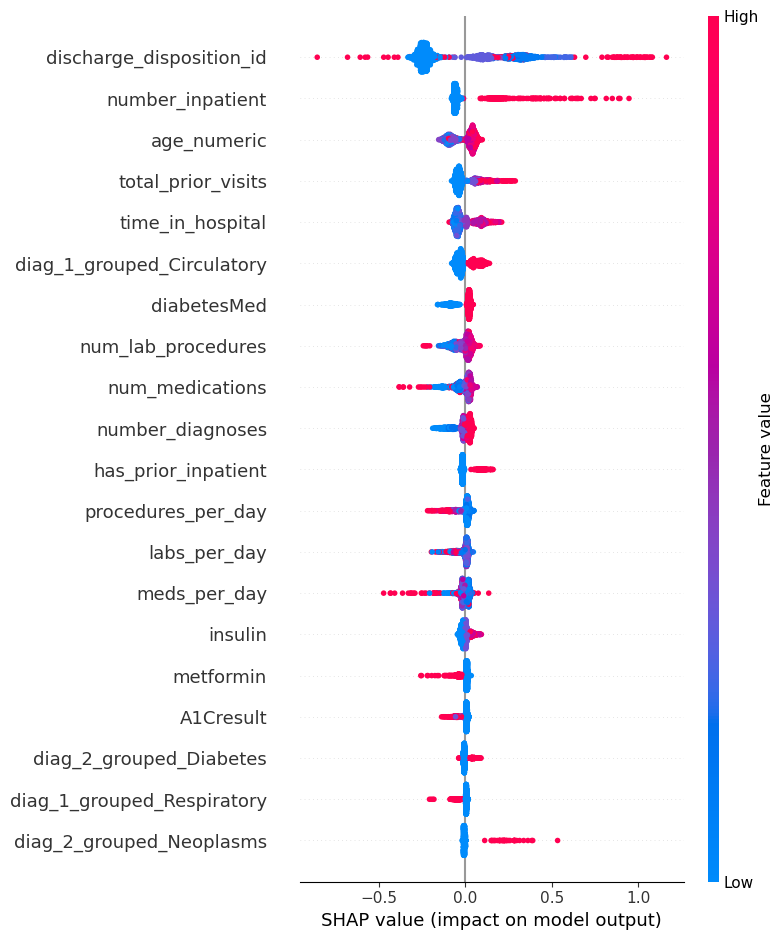

In [3]:
plt.figure(figsize=(12, 10))
shap.summary_plot(shap_values, X_sample, show=False)
plt.tight_layout()
plt.savefig('../figures/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

In [4]:
import pandas as pd

df_raw = pd.read_csv('../data/diabetic_data.csv')
print(df_raw['discharge_disposition_id'].value_counts().head(15))

discharge_disposition_id
1     60234
3     13954
6     12902
18     3691
2      2128
22     1993
11     1642
5      1184
25      989
4       815
7       623
23      412
13      399
14      372
28      139
Name: count, dtype: int64


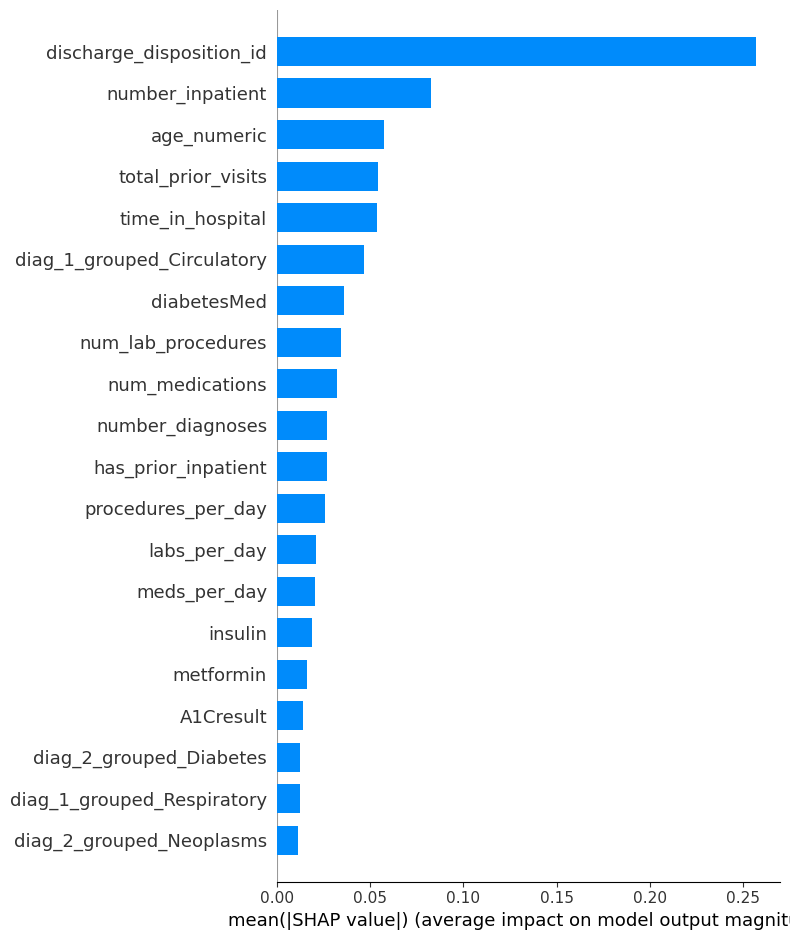

In [9]:
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_sample, plot_type='bar', show=False)
plt.tight_layout()
plt.savefig('../figures/shap_importance_bar.png', dpi=150, bbox_inches='tight')
plt.show()

Patient predicted probability: 0.591


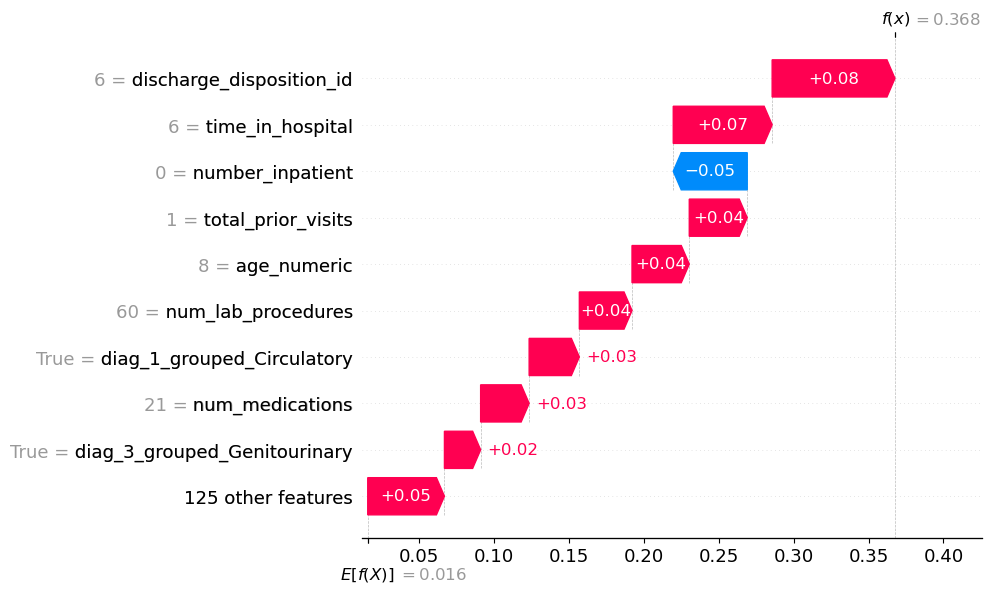

<Figure size 640x480 with 0 Axes>

In [12]:
high_risk_indices = np.where(best_xgb.predict_proba(X_sample)[:, 1] > 0.5)[0]

if len(high_risk_indices) > 0:
    patient_idx = high_risk_indices[0]
    prob = best_xgb.predict_proba(X_sample.iloc[[patient_idx]])[:, 1][0]
    print(f"Patient predicted probability: {prob:.3f}")
    
    shap.waterfall_plot(
        shap.Explanation(
            values=shap_values[patient_idx],
            base_values=explainer.expected_value,
            data=X_sample.iloc[patient_idx],
            feature_names=X_sample.columns.tolist()
        )
    )
    plt.tight_layout()
    plt.savefig('../figures/shap_waterfall_high_risk.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("No high-risk patients found in sample")